<a href="https://www.kaggle.com/code/chumakoleksandr/hw30-09?scriptVersionId=354185438" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import torch
import matplotlib.pyplot as plt

from collections import Counter
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
data_dir = "/kaggle/input/datasets/sshikamaru/fruit-recognition/train/train"

dataset = datasets.ImageFolder(data_dir)

print("Кількість зображень:", len(dataset))
print("Кількість класів:", len(dataset.classes))
print("Класи:", dataset.classes)
print("Індекси класів:", dataset.class_to_idx)

counts = Counter(dataset.targets)

for i, name in enumerate(dataset.classes):
    print(f"{name}: {counts[i]}")

Кількість зображень: 16854
Кількість класів: 33
Класи: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Індекси класів: {'Apple Braeburn': 0, 'Apple Granny Smith': 1, 'Apricot': 2, 'Avocado': 3, 'Banana': 4, 'Blueberry': 5, 'Cactus fruit': 6, 'Cantaloupe': 7, 'Cherry': 8, 'Clementine': 9, 'Corn': 10, 'Cucumber Ripe': 11, 'Grape Blue': 12, 'Kiwi': 13, 'Lemon': 14, 'Limes': 15, 'Mango': 16, 'Onion White': 17, 'Orange': 18, 'Papaya': 19, 'Passion Fruit': 20, 'Peach': 21, 'Pear': 22, 'Pepper Green': 23, 'Pepper Red': 24, 'Pineapple': 25, 'Plum': 26, 'Pomegranate': 27, 'Potato Red': 28, 'Raspberry': 29, 'Strawberry': 30, 'Tomato': 3

Файл: /kaggle/input/datasets/sshikamaru/fruit-recognition/train/train/Apple Braeburn/Apple Braeburn_0.jpg
Розмір: (100, 100)
Клас: Apple Braeburn


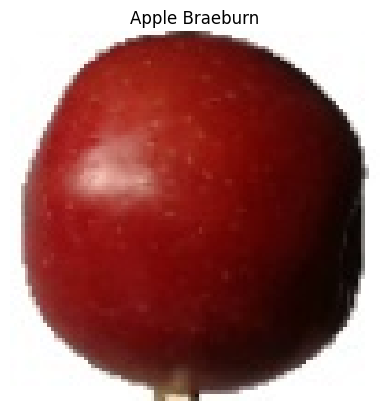

In [3]:
img, label = dataset[0]

print("Файл:", dataset.samples[0][0])
print("Розмір:", img.size)
print("Клас:", dataset.classes[label])

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [4]:
train_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [5]:
class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = self.transformer(img)
        return img, label

In [6]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = TransformDataset(train_data, train_transformer)
test_dataset = TransformDataset(test_data, test_transformer)

print("Тренувальні зображення:", len(train_dataset))
print("Тестові зображення:", len(test_dataset))

Тренувальні зображення: 13483
Тестові зображення: 3371


In [7]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("Розмір пакета:", images.shape)
print("Розмір міток:", labels.shape)

Розмір пакета: torch.Size([32, 3, 224, 224])
Розмір міток: torch.Size([32])


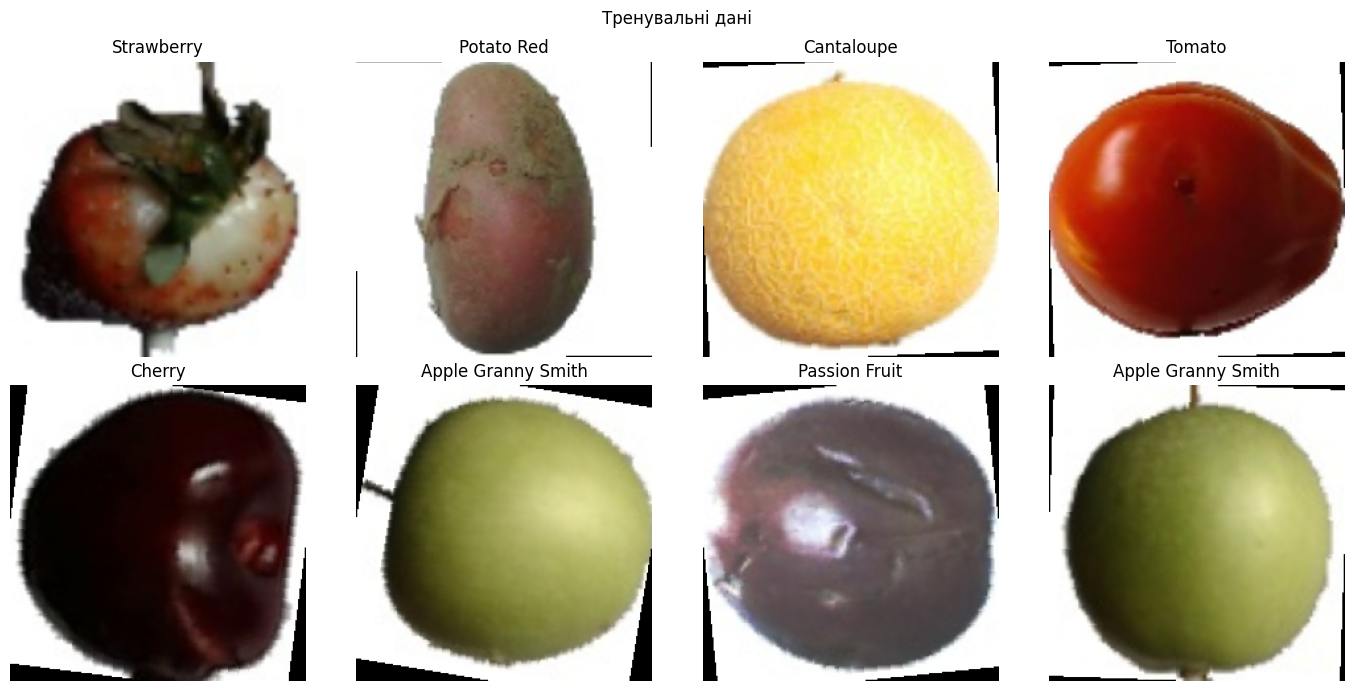

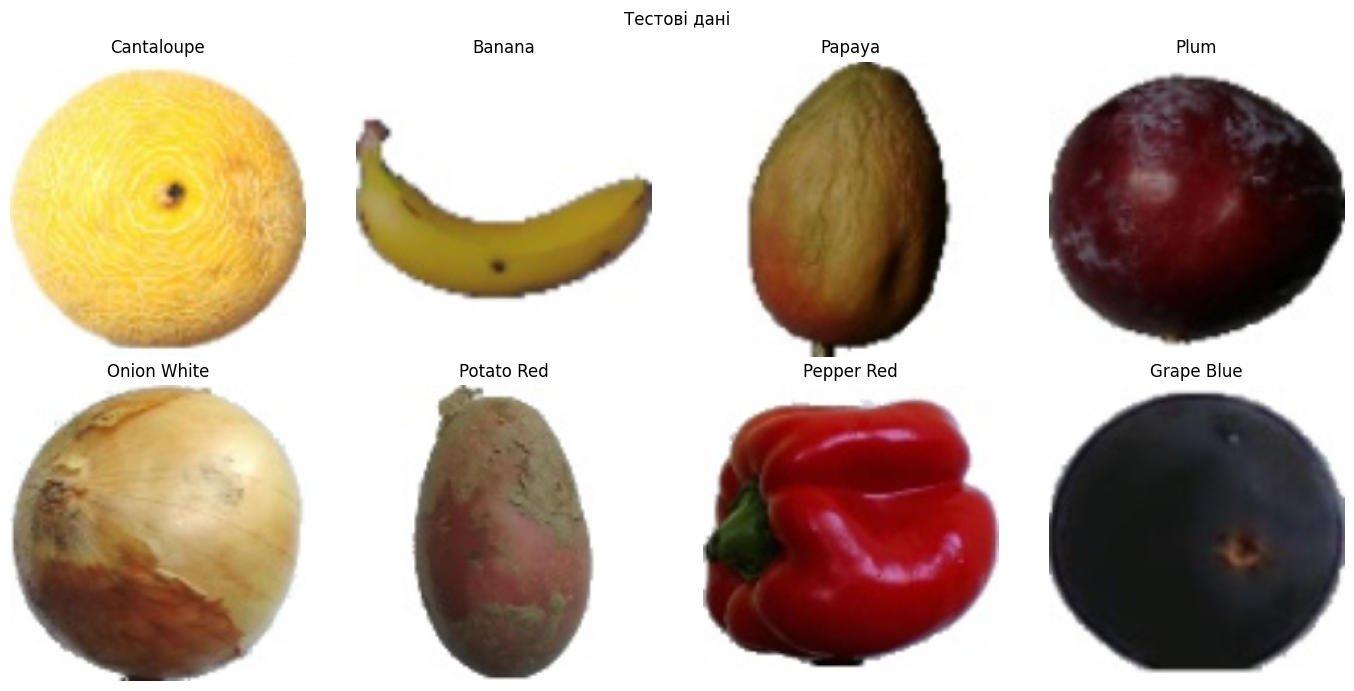

In [8]:
for title, loader in [
    ("Тренувальні дані", train_loader),
    ("Тестові дані", test_loader)
]:
    images, labels = next(iter(loader))

    plt.figure(figsize=(14, 7))
    plt.suptitle(title)

    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].permute(1, 2, 0))
        plt.title(dataset.classes[labels[i].item()])
        plt.axis("off")

    plt.tight_layout()
    plt.show()